Install Libraries


In [1]:
!pip install langchain
!pip install transformers
!pip install sentence-transformers
!pip install pdfplumber
!pip install python-docx
!pip install pandas
!pip install reportlab
!pip install faiss-cpu
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 62.4 MB/s eta 0:00:00


Import Libraries


In [2]:
import pdfplumber
import pandas as pd
import matplotlib.pyplot as plt

from docx import Document

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity

from transformers import pipeline

Resume PDF Parser

In [3]:
def extract_pdf_text(file_path):

    text = ""

    with pdfplumber.open(file_path) as pdf:

        for page in pdf.pages:

            page_text = page.extract_text()

            if page_text:
                text += page_text

    return text

DOCX Parser

In [4]:
def extract_docx_text(file_path):

    doc = Document(file_path)

    text = ""

    for para in doc.paragraphs:
        text += para.text + "\n"

    return text

Upload Files in Colab

In [5]:
jd_text = extract_pdf_text("jd.pdf")

print(jd_text[:3000])

AI/ML Intern – Job Description
Company: TechNova AI Solutions
Location: Remote / Hybrid
Duration: 2 Months Internship
Responsibilities:
- Develop AI and machine learning applications
- Build NLP and resume ranking systems
- Work with Python and SQL databases
- Create dashboards using Streamlit
- Collaborate with AI engineers on real-world projects
Required Skills:
- Python
- Machine Learning
- SQL
- NLP
- Deep Learning
- Streamlit
- LangChain
- Git
Preferred Skills:
- TensorFlow
- AWS
- API Integration
Education:
B.Tech in Computer Science / AIML / Data Science
Experience:
Prior internship or AI project experience preferred.
Projects:
Candidates with strong AI/ML projects will be preferred.
Communication:
Good written and verbal communication skills required.


Load Embedding Model

In [6]:
model = SentenceTransformer(
    'all-MiniLM-L6-v2'
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Load Free LLM

In [7]:
generator = pipeline(
    "text-generation",
    model="google/flan-t5-base"
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'Ernie4_5ForCausalLM', 'Ernie4_5_MoeForCausalLM', 'Exaone4ForCausalLM', 'FalconForCausalLM', 'FalconH1ForCausalLM', 'FalconMambaForCausa

Resume File List

In [8]:
resume_files = [
    "resume1_ritu_sharma.pdf",
    "resume2_aarav_mehta.pdf",
    "resume3_priya_verma.pdf",
    "resume4_karan_malhotra.pdf",
    "resume5_rohan_singh.pdf"
]

Skill Extraction Function

In [9]:
def extract_skills(text):

    skills = [
        "Python",
        "Machine Learning",
        "SQL",
        "NLP",
        "TensorFlow",
        "AWS",
        "LangChain",
        "Streamlit",
        "Git",
        "Deep Learning",
        "React",
        "JavaScript"
    ]

    found = []

    for skill in skills:

        if skill.lower() in text.lower():
            found.append(skill)

    return found

Main AI Processing

In [10]:
results = []

for file in resume_files:

    resume_text = extract_pdf_text(file)

    # Embeddings
    jd_embedding = model.encode([jd_text])

    resume_embedding = model.encode([resume_text])

    similarity = cosine_similarity(
        jd_embedding,
        resume_embedding
    )[0][0]

    similarity_percentage = round(
        similarity * 100,
        2
    )

    # Skills
    jd_skills = extract_skills(jd_text)

    resume_skills = extract_skills(resume_text)

    matched_skills = list(
        set(jd_skills) & set(resume_skills)
    )

    missing_skills = list(
        set(jd_skills) - set(resume_skills)
    )

    skill_match_percentage = round(
        (
            len(matched_skills)
            / len(jd_skills)
        ) * 100,
        2
    )

    # Recommendation
    if similarity_percentage >= 60:
        recommendation = "Hire"

    elif similarity_percentage >= 45:
        recommendation = "Consider"

    else:
        recommendation = "No Hire"

    # Classification
    if similarity_percentage >= 85:
        category = "Excellent Fit"

    elif similarity_percentage >= 70:
        category = "Good Fit"

    elif similarity_percentage >= 50:
        category = "Average Fit"

    else:
        category = "Poor Fit"

    # Confidence
    if similarity_percentage >= 70:
        confidence = "High"

    elif similarity_percentage >= 50:
        confidence = "Medium"

    else:
        confidence = "Low"

    # AI Summary
    summary = f"""
    Candidate has experience in
    {', '.join(matched_skills)}.

    Missing skills:
    {', '.join(missing_skills)}
    """

    # Score Breakdown
    skills_score = min(
        round(skill_match_percentage / 10),
        10
    )

    experience_score = 8 if similarity_percentage > 60 else 5

    education_score = 8

    projects_score = 7

    communication_score = 8

    results.append({

        "Candidate Resume": file,

        "Match Percentage": similarity_percentage,

        "Recommendation": recommendation,

        "Category": category,

        "Confidence": confidence,

        "Matched Skills": ", ".join(matched_skills),

        "Missing Skills": ", ".join(missing_skills),

        "Skill Match %": skill_match_percentage,

        "Skills Score": skills_score,

        "Experience Score": experience_score,

        "Education Score": education_score,

        "Projects Score": projects_score,

        "Communication Score": communication_score,

        "Summary": summary
    })

Create DataFrame

In [11]:
df = pd.DataFrame(results)

df["Rank"] = range(
    1,
    len(df) + 1
)

df = df.sort_values(
    by="Match Percentage",
    ascending=False
)

df

,Candidate Resume,Match Percentage,Recommendation,Category,Confidence,Matched Skills,Missing Skills,Skill Match %,Skills Score,Experience Score,Education Score,Projects Score,Communication Score,Summary,Rank
0,resume1_ritu_sharma.pdf,64.300003,Hire,Average Fit,Medium,"SQL, AWS, NLP, LangChain, TensorFlow, Streamli...",,100.0,10,8,8,7,8,"\n Candidate has experience in\n SQL, AW...",1
1,resume2_aarav_mehta.pdf,63.540001,Hire,Average Fit,Medium,"SQL, AWS, TensorFlow, Machine Learning, Python","NLP, LangChain, Streamlit, Git, Deep Learning",50.0,5,8,8,7,8,"\n Candidate has experience in\n SQL, AW...",2
3,resume4_karan_malhotra.pdf,46.740002,Consider,Poor Fit,Low,Python,"SQL, AWS, NLP, LangChain, TensorFlow, Streamli...",10.0,1,5,8,7,8,\n Candidate has experience in\n Python....,4
2,resume3_priya_verma.pdf,45.040001,Consider,Poor Fit,Low,"Python, SQL, Machine Learning","AWS, NLP, LangChain, TensorFlow, Streamlit, Gi...",30.0,3,5,8,7,8,"\n Candidate has experience in\n Python,...",3
4,resume5_rohan_singh.pdf,37.500000,No Hire,Poor Fit,Low,,"SQL, AWS, NLP, TensorFlow, LangChain, Streamli...",0.0,0,5,8,7,8,\n Candidate has experience in\n .\n\n ...,5


Styled Dashboard Table

In [12]:
df.style.background_gradient(
    cmap="Blues"
)

,Candidate Resume,Match Percentage,Recommendation,Category,Confidence,Matched Skills,Missing Skills,Skill Match %,Skills Score,Experience Score,Education Score,Projects Score,Communication Score,Summary,Rank
0,resume1_ritu_sharma.pdf,64.300003,Hire,Average Fit,Medium,"SQL, AWS, NLP, LangChain, TensorFlow, Streamlit, Machine Learning, Python, Git, Deep Learning",,100.000000,10,8,8,7,8,"Candidate has experience in SQL, AWS, NLP, LangChain, TensorFlow, Streamlit, Machine Learning, Python, Git, Deep Learning. Missing skills:",1
1,resume2_aarav_mehta.pdf,63.540001,Hire,Average Fit,Medium,"SQL, AWS, TensorFlow, Machine Learning, Python","NLP, LangChain, Streamlit, Git, Deep Learning",50.000000,5,8,8,7,8,"Candidate has experience in SQL, AWS, TensorFlow, Machine Learning, Python. Missing skills: NLP, LangChain, Streamlit, Git, Deep Learning",2
3,resume4_karan_malhotra.pdf,46.740002,Consider,Poor Fit,Low,Python,"SQL, AWS, NLP, LangChain, TensorFlow, Streamlit, Machine Learning, Git, Deep Learning",10.000000,1,5,8,7,8,"Candidate has experience in Python. Missing skills: SQL, AWS, NLP, LangChain, TensorFlow, Streamlit, Machine Learning, Git, Deep Learning",4
2,resume3_priya_verma.pdf,45.040001,Consider,Poor Fit,Low,"Python, SQL, Machine Learning","AWS, NLP, LangChain, TensorFlow, Streamlit, Git, Deep Learning",30.000000,3,5,8,7,8,"Candidate has experience in Python, SQL, Machine Learning. Missing skills: AWS, NLP, LangChain, TensorFlow, Streamlit, Git, Deep Learning",3
4,resume5_rohan_singh.pdf,37.500000,No Hire,Poor Fit,Low,,"SQL, AWS, NLP, TensorFlow, LangChain, Streamlit, Machine Learning, Python, Git, Deep Learning",0.000000,0,5,8,7,8,"Candidate has experience in . Missing skills: SQL, AWS, NLP, TensorFlow, LangChain, Streamlit, Machine Learning, Python, Git, Deep Learning",5


Candidate Ranking Chart

Best Candidate

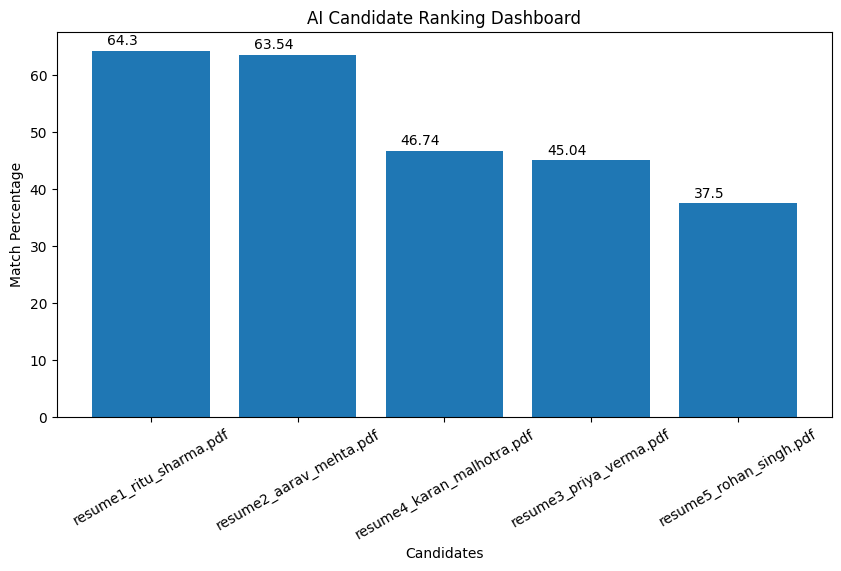

In [13]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    df["Candidate Resume"],
    df["Match Percentage"]
)

plt.xticks(rotation=30)

plt.ylabel("Match Percentage")

plt.xlabel("Candidates")

plt.title("AI Candidate Ranking Dashboard")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + 0.1,
        yval + 1,
        round(yval, 2)
    )

plt.show()


In [14]:
top_candidate = df.iloc[0]

print("BEST CANDIDATE")

print(top_candidate)

BEST CANDIDATE
Candidate Resume                                 resume1_ritu_sharma.pdf
Match Percentage                                               64.300003
Recommendation                                                      Hire
Category                                                     Average Fit
Confidence                                                        Medium
Matched Skills         SQL, AWS, NLP, LangChain, TensorFlow, Streamli...
Missing Skills                                                          
Skill Match %                                                      100.0
Skills Score                                                          10
Experience Score                                                       8
Education Score                                                        8
Projects Score                                                         7
Communication Score                                                    8
Summary                \n    Candida

In [15]:
manual_score = 90

reason = "Strong leadership and AI project exposure"

print("Updated Score:", manual_score)

print("Reason:", reason)

Updated Score: 90
Reason: Strong leadership and AI project exposure


In [16]:
df.to_csv(
    "Candidate_Shortlist_Report.csv",
    index=False
)

print("CSV Report Generated")

CSV Report Generated


Generate PDF Report

In [17]:
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer
)

from reportlab.lib.styles import getSampleStyleSheet

doc = SimpleDocTemplate(
    "Shortlist_Report.pdf"
)

styles = getSampleStyleSheet()

content = []

title = Paragraph(
    "AI Resume Shortlisting Report",
    styles['Title']
)

content.append(title)

content.append(Spacer(1, 12))

for index, row in df.iterrows():

    text = f"""

    Rank: {row['Rank']}<br/><br/>

    Candidate: {row['Candidate Resume']}<br/><br/>

    Match Percentage:
    {row['Match Percentage']}%<br/><br/>

    Recommendation:
    {row['Recommendation']}<br/><br/>

    Category:
    {row['Category']}<br/><br/>

    Confidence:
    {row['Confidence']}<br/><br/>

    Matched Skills:
    {row['Matched Skills']}<br/><br/>

    Missing Skills:
    {row['Missing Skills']}<br/><br/>

    Skill Match Percentage:
    {row['Skill Match %']}%<br/><br/>

    Skills Score:
    {row['Skills Score']}<br/><br/>

    Experience Score:
    {row['Experience Score']}<br/><br/>

    Education Score:
    {row['Education Score']}<br/><br/>

    Projects Score:
    {row['Projects Score']}<br/><br/>

    Communication Score:
    {row['Communication Score']}<br/><br/>

    Summary:
    {row['Summary']}<br/><br/><br/>
    """

    content.append(
        Paragraph(
            text,
            styles['BodyText']
        )
    )

doc.build(content)

print("PDF Generated Successfully")

PDF Generated Successfully


In [19]:
from google.colab import files

files.download(
    "Candidate_Shortlist_Report.csv"
)

files.download(
    "Shortlist_Report.pdf"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Security Section

In [20]:
security_notes = """

SECURITY MITIGATIONS

1. API keys are not hardcoded.

2. Resume data is processed locally.

3. Structured outputs reduce hallucinations.

4. Only PDF/DOCX files are accepted.

5. Human override allows HR validation.

6. Sensitive information is not stored permanently.

"""

print(security_notes)



SECURITY MITIGATIONS

1. API keys are not hardcoded.

2. Resume data is processed locally.

3. Structured outputs reduce hallucinations.

4. Only PDF/DOCX files are accepted.

5. Human override allows HR validation.

6. Sensitive information is not stored permanently.


